# EJERCICIO 2 Propio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from random import randrange
import datetime
from scipy.stats import norm

# Cargar el dataset
df = pd.read_csv('cybersecurity_attacks.csv')

# Mostrar el total de eventos registrados
total_eventos = len(df)
print(f"Total de eventos registrados: {total_eventos}")

# Calcular el porcentaje de uso de los puertos
# Primero, verifiquemos los tipos de protocolo (puerto).
print (df)


Total de eventos registrados: 40000
                 Timestamp Source IP Address Destination IP Address  \
0      2023-05-30 06:33:58     103.216.15.12           84.9.164.252   
1      2020-08-26 07:08:30    78.199.217.198         66.191.137.154   
2      2022-11-13 08:23:25      63.79.210.48          198.219.82.17   
3      2023-07-02 10:38:46     163.42.196.10        101.228.192.255   
4      2023-07-16 13:11:07     71.166.185.76        189.243.174.238   
...                    ...               ...                    ...   
39995  2023-05-26 14:08:42      26.36.109.26         121.100.75.240   
39996  2023-03-27 00:38:27      17.21.163.81         196.108.134.78   
39997  2022-03-31 01:45:49     162.35.217.57            98.107.0.15   
39998  2023-09-22 18:32:38    208.72.233.205         173.79.112.252   
39999  2023-10-10 11:59:52     14.102.21.108           109.198.45.7   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
0            31225             1761

In [3]:

# 1. Eliminar filas duplicadas
df = df.drop_duplicates()
print("\nDespués de eliminar duplicados:")
print(df.head())


Después de eliminar duplicados:
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data 

In [4]:
# 2. Manejar valores nulos
# a. Eliminar filas con valores nulos
df_sin_duplicados = df.drop_duplicates()
print("DataFrame sin registros duplicados:")
print(df_sin_duplicados)
print("\n")

DataFrame sin registros duplicados:
                 Timestamp Source IP Address Destination IP Address  \
0      2023-05-30 06:33:58     103.216.15.12           84.9.164.252   
1      2020-08-26 07:08:30    78.199.217.198         66.191.137.154   
2      2022-11-13 08:23:25      63.79.210.48          198.219.82.17   
3      2023-07-02 10:38:46     163.42.196.10        101.228.192.255   
4      2023-07-16 13:11:07     71.166.185.76        189.243.174.238   
...                    ...               ...                    ...   
39995  2023-05-26 14:08:42      26.36.109.26         121.100.75.240   
39996  2023-03-27 00:38:27      17.21.163.81         196.108.134.78   
39997  2022-03-31 01:45:49     162.35.217.57            98.107.0.15   
39998  2023-09-22 18:32:38    208.72.233.205         173.79.112.252   
39999  2023-10-10 11:59:52     14.102.21.108           109.198.45.7   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
0            31225             1761

### Se valida que nos da un Future Warning en los comando usados en clase por lo cual se procede a corregir

In [5]:
df['Source Port'].fillna('DESCONOCIDO', inplace=True)
df['Destination Port'].fillna('DESCONOCIDO', inplace=True)

/tmp/ipykernel_1659/2523758318.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Source Port'].fillna('DESCONOCIDO', inplace=True)
/tmp/ipykernel_1659/2523758318.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

### Se corrige el furute Warning con estos comandos 

In [6]:
df['Source Port'] = df['Source Port'].fillna('DESCONOCIDO')
df['Destination Port'] = df['Destination Port'].fillna('DESCONOCIDO')


### Se valida que el archivo no tiene errores pero de igual manera se aplica las correciones en caso de ingresar otros archivos que si lo tengan.

In [7]:
print(df)

                 Timestamp Source IP Address Destination IP Address  \
0      2023-05-30 06:33:58     103.216.15.12           84.9.164.252   
1      2020-08-26 07:08:30    78.199.217.198         66.191.137.154   
2      2022-11-13 08:23:25      63.79.210.48          198.219.82.17   
3      2023-07-02 10:38:46     163.42.196.10        101.228.192.255   
4      2023-07-16 13:11:07     71.166.185.76        189.243.174.238   
...                    ...               ...                    ...   
39995  2023-05-26 14:08:42      26.36.109.26         121.100.75.240   
39996  2023-03-27 00:38:27      17.21.163.81         196.108.134.78   
39997  2022-03-31 01:45:49     162.35.217.57            98.107.0.15   
39998  2023-09-22 18:32:38    208.72.233.205         173.79.112.252   
39999  2023-10-10 11:59:52     14.102.21.108           109.198.45.7   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
0            31225             17616     ICMP            503        Dat

### Se ordea de lo mas antiguo al mas reciente tanto en fechas como en horas

In [32]:
df['Fecha'] = pd.to_datetime(df['Timestamp'])

# Ordenar el DataFrame por la columna 'Fecha' de menor a mayor
df_ordenado = df.sort_values(by='Fecha')
print (df_ordenado)

                Timestamp Source IP Address Destination IP Address  \
17494 2020-01-01 00:43:27     159.63.40.232           84.35.86.112   
33427 2020-01-01 01:14:07   203.224.244.176          12.67.144.136   
26028 2020-01-01 03:02:42     152.81.184.63          81.199.149.14   
38419 2020-01-01 03:11:48   161.219.235.160         30.142.166.219   
29339 2020-01-01 03:29:20     21.158.215.82         124.104.48.211   
...                   ...               ...                    ...   
4778  2023-10-11 12:29:23    130.231.62.201         137.34.162.176   
13787 2023-10-11 12:36:21      15.87.212.52        155.139.226.246   
29107 2023-10-11 17:44:41     19.103.201.84        153.183.223.203   
27995 2023-10-11 18:50:41    173.249.245.31          17.244.142.70   
11677 2023-10-11 19:34:23     22.36.249.229          169.96.251.75   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
17494        30053             56285      UDP           1428        Data   
33427  

In [33]:
# Separar la columna Timestamp en Fecha y Hora
df_ordenado['Fecha'] = pd.to_datetime(df_ordenado['Timestamp']).dt.date
# Crear la columna 'Hora' en df_ordenado
df_ordenado['Hora'] = pd.to_datetime(df_ordenado['Timestamp']).dt.time

# Acceder a las columnas correctas
print(df_ordenado['Fecha'])
print(df_ordenado['Hora'])

17494    2020-01-01
33427    2020-01-01
26028    2020-01-01
38419    2020-01-01
29339    2020-01-01
            ...    
4778     2023-10-11
13787    2023-10-11
29107    2023-10-11
27995    2023-10-11
11677    2023-10-11
Name: Fecha, Length: 40000, dtype: object
17494    00:43:27
33427    01:14:07
26028    03:02:42
38419    03:11:48
29339    03:29:20
           ...   
4778     12:29:23
13787    12:36:21
29107    17:44:41
27995    18:50:41
11677    19:34:23
Name: Hora, Length: 40000, dtype: object


### Se realiza un grafico de barra sobre los accesos que se tiene y por donde va el trafico

#### Adicional se tiene un Furute Warning sobre los graficos 

/tmp/ipykernel_1659/1042910834.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=traffic_counts.index, y=traffic_counts.values, palette="viridis")


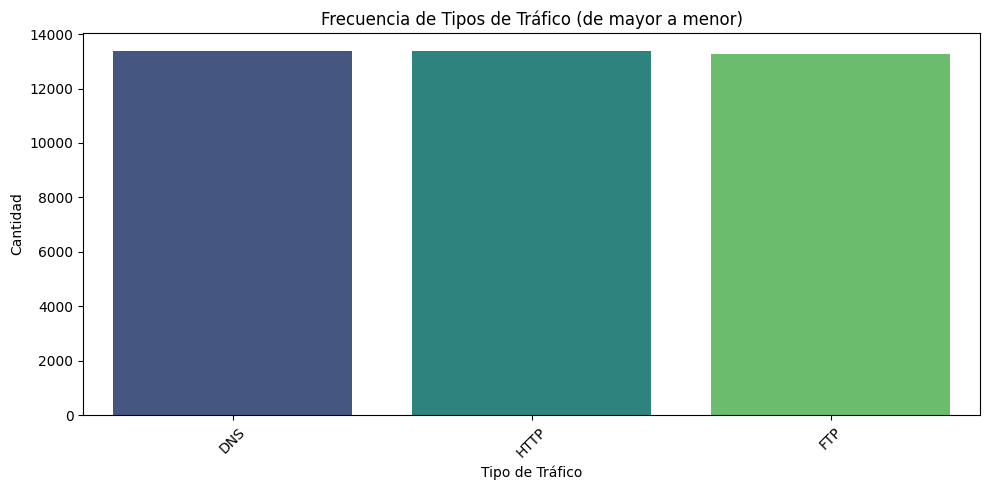

In [24]:
# Contar la frecuencia de cada tipo de tráfico
traffic_counts = df['Traffic Type'].value_counts()

# Ordenar los valores de mayor a menor
traffic_counts = traffic_counts.sort_values(ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=traffic_counts.index, y=traffic_counts.values, palette="viridis")

# Añadir etiquetas y título
plt.title("Frecuencia de Tipos de Tráfico (de mayor a menor)")
plt.xlabel("Tipo de Tráfico")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Se corrige el errro de Future Warning en el hue and set `legend=False`

Traffic Type
DNS     13376
HTTP    13360
FTP     13264
Name: count, dtype: int64


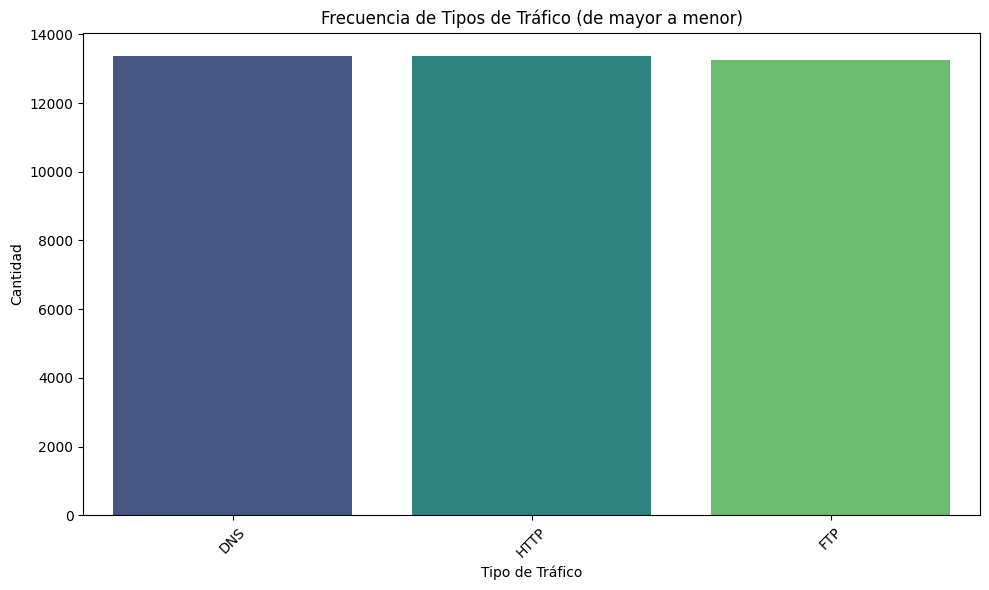

In [25]:
traffic_counts = df['Traffic Type'].value_counts()

# Ordenar los valores de mayor a menor
traffic_counts = traffic_counts.sort_values(ascending=False)
print (traffic_counts)
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=traffic_counts.index, y=traffic_counts.values, hue=traffic_counts.index, palette="viridis", legend=False)

# Añadir etiquetas y título
plt.title("Frecuencia de Tipos de Tráfico (de mayor a menor)")
plt.xlabel("Tipo de Tráfico")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Se tiene un trafico de pastel sobre los tipos de ataques y cuales son los que mas se ejecutan

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


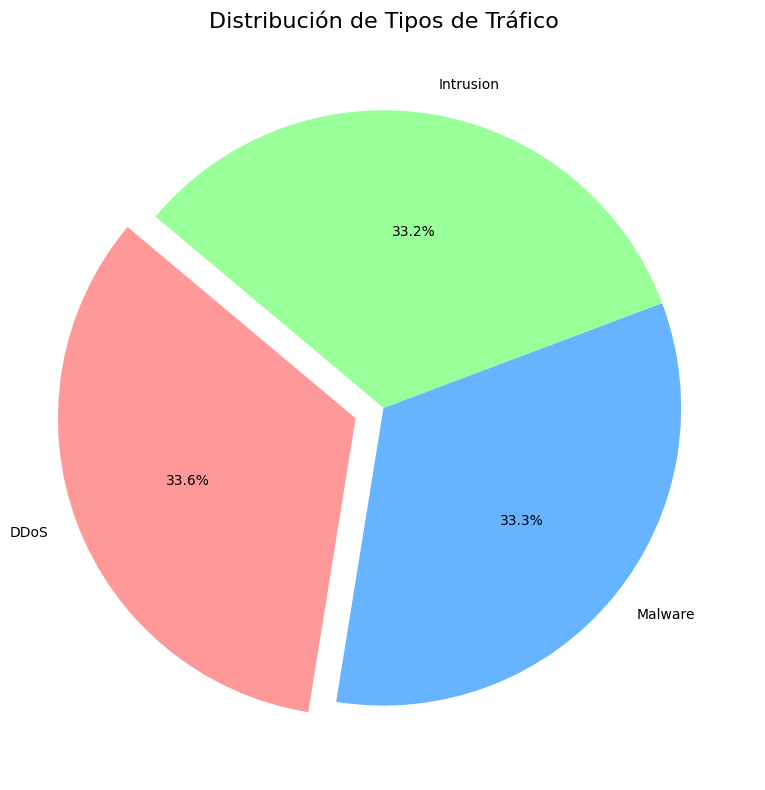

In [26]:
traffic_counts = df['Attack Type'].value_counts()
print(traffic_counts)

# Filtrar valores pequeños
threshold = 10
traffic_counts_filtered = traffic_counts[traffic_counts >= threshold]
others_count = traffic_counts[traffic_counts < threshold].sum()
if others_count > 0:
    traffic_counts_filtered['Otros'] = others_count

# Crear el gráfico de pastel
plt.figure(figsize=(12, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
explode = [0.1 if i == traffic_counts_filtered.idxmax() else 0 for i in traffic_counts_filtered.index]
plt.pie(traffic_counts_filtered, labels=traffic_counts_filtered.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode)

# Añadir título
plt.title("Distribución de Tipos de Tráfico", fontsize=16)

# Guardar y mostrar el gráfico
plt.tight_layout()
plt.savefig('distribucion_tipos_trafico.png', dpi=300, bbox_inches='tight')
plt.show()

### Se realiza un grafico de barras sobre el protocolo mas usado en el lapso de tiempo indicado

<Figure size 2400x600 with 0 Axes>

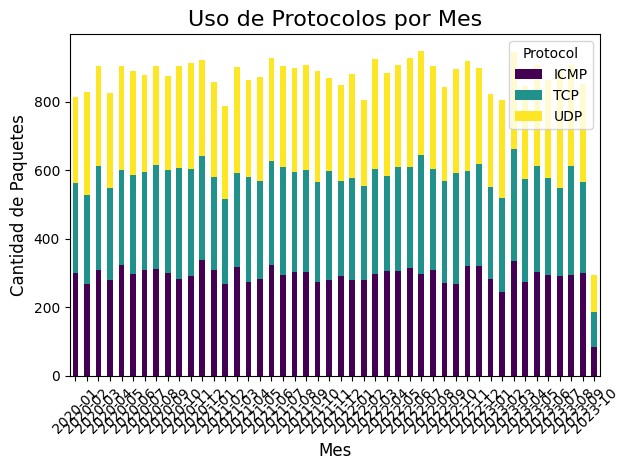

In [27]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Month'] = df['Timestamp'].dt.to_period('M')
protocol_usage = df.groupby(['Month', 'Protocol']).size().unstack(fill_value=0)
# Configurar el tamaño del gráfico
plt.figure(figsize=(24, 6))

# Crear el gráfico de barras apiladas
protocol_usage.plot(kind='bar', stacked=True, colormap='viridis')

# Añadir título y etiquetas
plt.title('Uso de Protocolos por Mes', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Paquetes', fontsize=12)

# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45)

# Mostrar la leyenda
#plt.legend(title='Protocolo', bbox_to_anchor=(1.25, 1), loc='upper left')

# Ajustar el layout para que no se corten las etiquetas
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Se realiza el mapa de calor sobre el nivel de seguirdad a lo largo del tiempo 

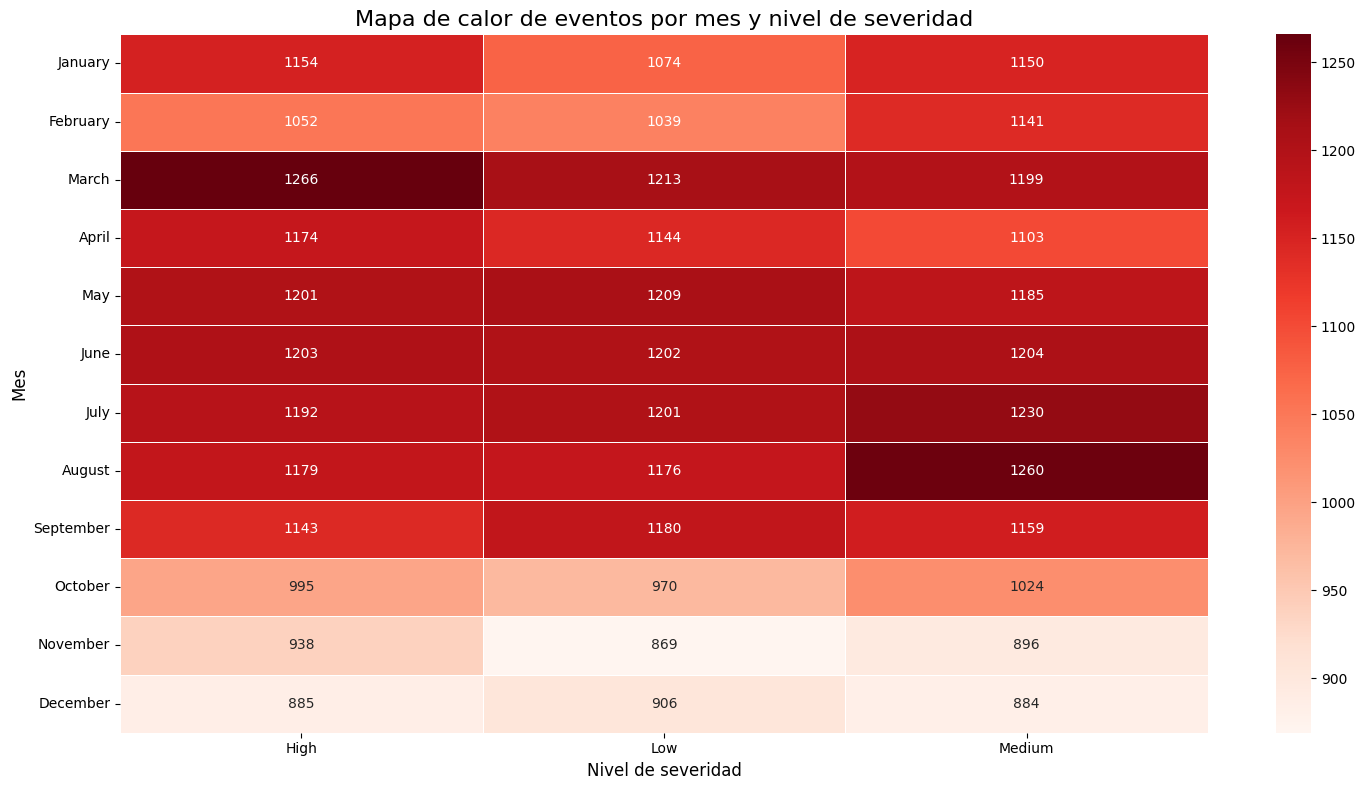

In [28]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extraer el mes y el nivel de severidad
df['mes'] = df['Timestamp'].dt.month_name()  # Extraer el nombre del mes
df['Severity Level'] = df['Severity Level'].astype(str)  # Asegurar que 'Severity Level' sea string

# Crear una tabla pivote con la cantidad de eventos por mes y nivel de severidad
heatmap_data = df.pivot_table(index="mes", columns="Severity Level", aggfunc="size", fill_value=0)

# Reordenar los meses en orden lógico
meses_ordenados = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
heatmap_data = heatmap_data.reindex(meses_ordenados)

# Crear el mapa de calor
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap="Reds", annot=True, fmt="d", linewidths=0.5)

# Configurar etiquetas y título
plt.title("Mapa de calor de eventos por mes y nivel de severidad", fontsize=16)
plt.xlabel("Nivel de severidad", fontsize=12)
plt.ylabel("Mes", fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Se realiza un grafico de tiempo sobre las alertas sobre las IP o IDS sospechoso 

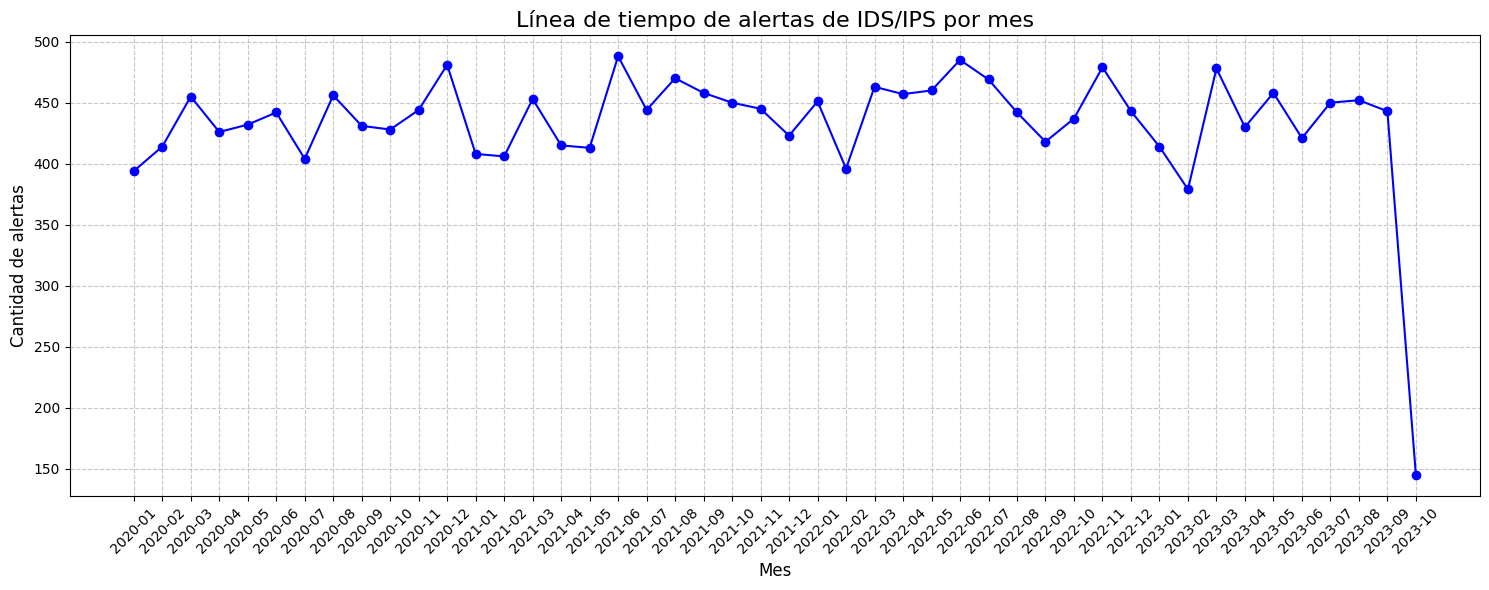

In [29]:
# Convertir la columna 'Timestamp' a tipo datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extraer el mes y el año
df['mes'] = df['Timestamp'].dt.to_period('M')  # Extraer el mes y el año en formato 'YYYY-MM'

# Contar la cantidad de alertas de IDS/IPS por mes
alerts_by_month = df.groupby('mes')['IDS/IPS Alerts'].count()

print 

# Convertir el índice a tipo string para mejor visualización
alerts_by_month.index = alerts_by_month.index.astype(str)

# Crear la línea de tiempo
plt.figure(figsize=(15, 6))
plt.plot(alerts_by_month.index, alerts_by_month.values, marker='o', linestyle='-', color='b')

# Configurar etiquetas y título
plt.title("Línea de tiempo de alertas de IDS/IPS por mes", fontsize=16)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Cantidad de alertas", fontsize=12)

# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45)

# Añadir una cuadrícula para mejor visualización
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()